In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import warnings
warnings.filterwarnings("ignore")

In [3]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [4]:
df = pd.read_csv("amazon_raw.csv")
df.head()
df.tail()
df.sample(10)
df.columns
df.shape
df.info()
df.describe()
df.describe(include="object")


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
count,1465,1465,1465,1465,1465,1465,1465,1463,1465,1465,1465,1465,1465,1465,1465,1465
unique,1351,1337,211,550,449,92,28,1143,1293,1194,1194,1194,1194,1212,1412,1465
top,B07JW9H4J1,"Fire-Boltt Ninja Call Pro Plus 1.83"" Smart Wat...",Computers&Accessories|Accessories&Peripherals|...,₹199,₹999,50%,4.1,"9,378",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AHIKJUDTVJ4T6DV6IUGFYZ5LXMPA,AE55KTFVNXYFD5FPY...","$@|\|TO$|-|,Sethu madhav,Akash Thakur,Burger P...","R3F4T5TRYPTMIG,R3DQIEC603E7AY,R1O4Z15FD40PV5,R...","Worked on iPhone 7 and didn’t work on XR,Good ...","I am not big on camera usage, personally. I wa...",https://m.media-amazon.com/images/I/413sCRKobN...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
freq,3,5,233,53,120,56,244,9,6,10,10,10,10,8,3,1


In [5]:
df.isnull().sum()

product_id             0
product_name           0
category               0
discounted_price       0
actual_price           0
discount_percentage    0
rating                 0
rating_count           2
about_product          0
user_id                0
user_name              0
review_id              0
review_title           0
review_content         0
img_link               0
product_link           0
dtype: int64

In [6]:
missing_percentage = df.isnull().mean() * 100

missing_percentage.sort_values(ascending=False)

rating_count           0.136519
product_id             0.000000
product_name           0.000000
category               0.000000
discounted_price       0.000000
actual_price           0.000000
discount_percentage    0.000000
rating                 0.000000
about_product          0.000000
user_id                0.000000
user_name              0.000000
review_id              0.000000
review_title           0.000000
review_content         0.000000
img_link               0.000000
product_link           0.000000
dtype: float64

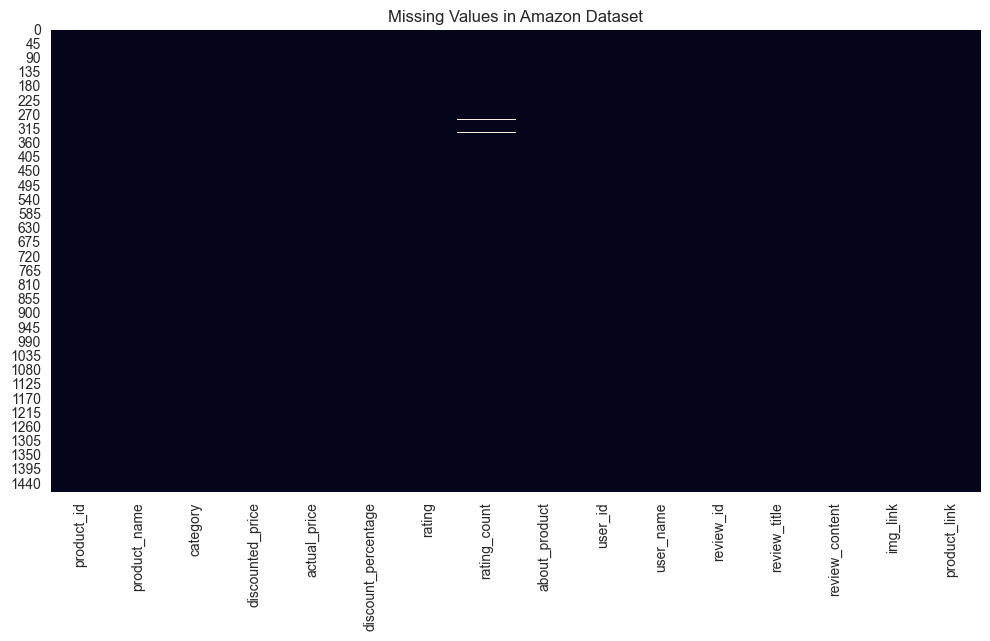

In [7]:
plt.figure(figsize=(12,6))

sns.heatmap(
    df.isnull(),
    cbar=False
)

plt.title("Missing Values in Amazon Dataset")
plt.show()

In [8]:
df.duplicated().sum()
df = df.drop_duplicates()
df.duplicated().sum()

0

In [9]:
df["discounted_price"] = (
    df["discounted_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)
df["discounted_price"] = pd.to_numeric(
    df["discounted_price"],
    errors="coerce"
)
df["actual_price"] = (
    df["actual_price"]
    .astype(str)
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
)

df["actual_price"] = pd.to_numeric(
    df["actual_price"],
    errors="coerce"
)

In [10]:
df["discount_percentage"] = (
    df["discount_percentage"]
    .astype(str)
    .str.replace("%", "", regex=False)
)
df["discount_percentage"] = pd.to_numeric(
    df["discount_percentage"],
    errors="coerce"
)

In [11]:
df["rating"].unique()
df["rating"] = pd.to_numeric(
    df["rating"],
    errors="coerce"
)
df["rating"].isnull().sum()
df["rating"] = df["rating"].fillna(
    df["rating"].median()
)
df["rating_count"] = (
    df["rating_count"]
    .astype(str)
    .str.replace(",", "", regex=False)
)
df["rating_count"] = (
    df["rating_count"]
    .astype(str)
    .str.replace(",", "", regex=False)
)

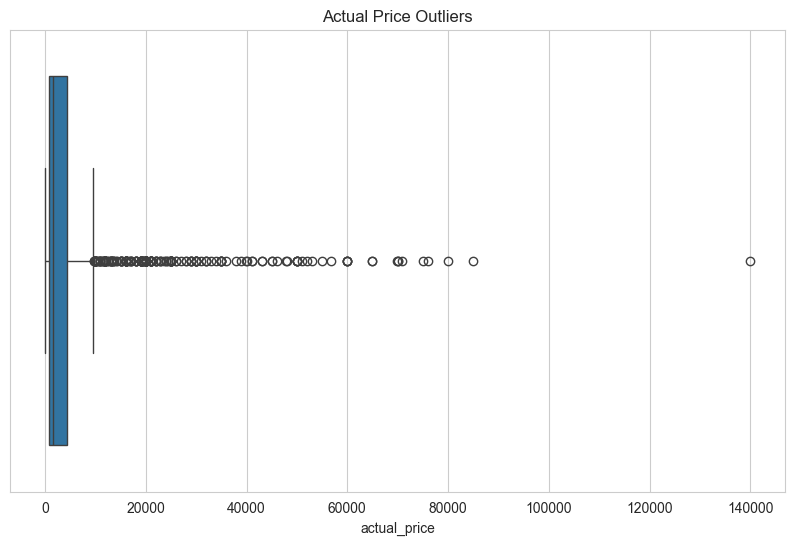

In [12]:
sns.boxplot(x=df["actual_price"])

plt.title("Actual Price Outliers")
plt.show()

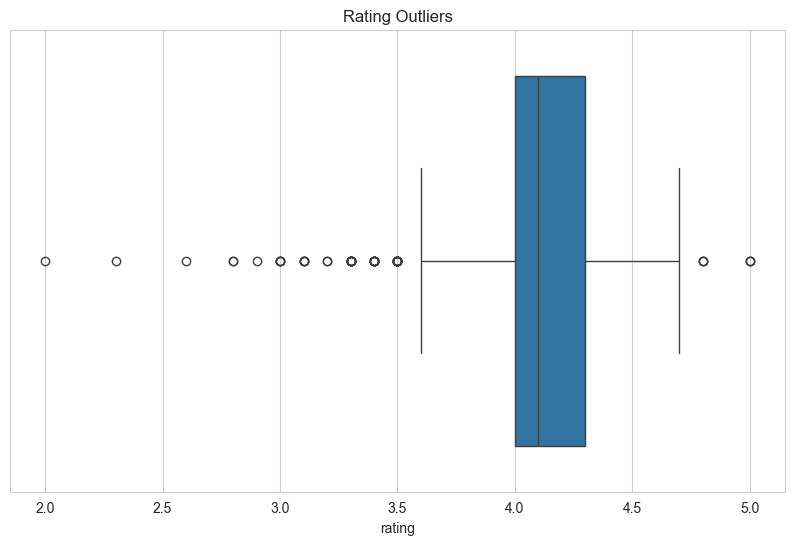

In [13]:
sns.boxplot(x=df["rating"])

plt.title("Rating Outliers")
plt.show()

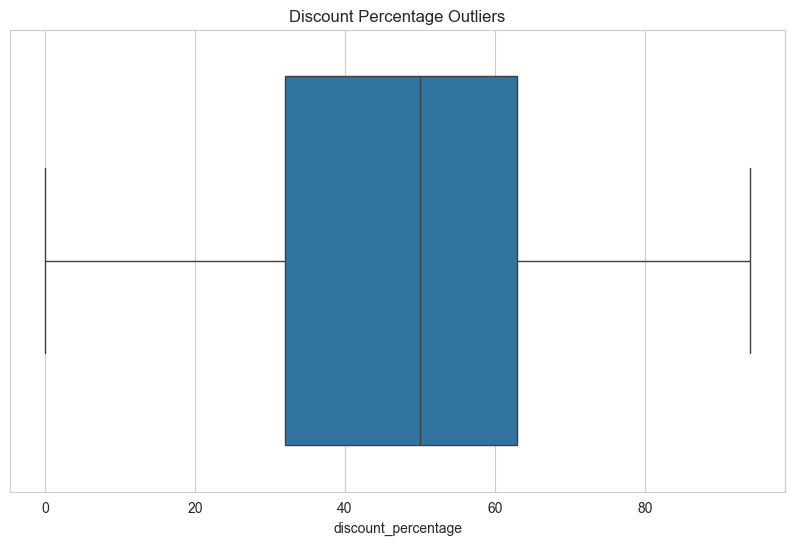

In [14]:
sns.boxplot(x=df["discount_percentage"])

plt.title("Discount Percentage Outliers")
plt.show()

In [15]:
Q1 = df["actual_price"].quantile(0.25)
Q3 = df["actual_price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [16]:
df = df[
    (df["actual_price"] >= lower) &
    (df["actual_price"] <= upper)
]

In [17]:
df["discount_amount"] = (
    df["actual_price"] -
    df["discounted_price"]
)
df["discount_ratio"] = (
    df["discount_amount"] /
    df["actual_price"]
)


In [18]:
df["price_category"] = np.select(
    [
        df["discounted_price"] < 500,
        df["discounted_price"].between(500, 2000),
        df["discounted_price"] > 2000
    ],
    [
        "Low Price",
        "Medium Price",
        "High Price"
    ],
    default="Unknown"
)
df["price_category"].value_counts()

price_category
Low Price       576
Medium Price    516
High Price      160
Name: count, dtype: int64

In [19]:
df["rating_category"] = np.select(
    [
        df["rating"] >= 4.5,
        df["rating"] >= 4.0,
        df["rating"] >= 3.0
    ],
    [
        "Excellent",
        "Good",
        "Average"
    ],
    default="Poor"
)


In [20]:
category_count = (
    df["category"]
    .value_counts()
)

category_count.head(10)

category
Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables                        233
Electronics|WearableTechnology|SmartWatches                                                               53
Electronics|Headphones,Earbuds&Accessories|Headphones|In-Ear                                              50
Electronics|HomeTheater,TV&Video|Accessories|RemoteControls                                               49
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|MixerGrinders                                  26
Computers&Accessories|Accessories&Peripherals|Keyboards,Mice&InputDevices|Mice                            24
Home&Kitchen|Kitchen&HomeAppliances|Vacuum,Cleaning&Ironing|Irons,Steamers&Accessories|Irons|DryIrons     24
Electronics|HomeTheater,TV&Video|Accessories|Cables|HDMICables                                            24
Home&Kitchen|Heating,Cooling&AirQuality|WaterHeaters&Geysers|InstantWaterHeaters                          23
Home&Kitch

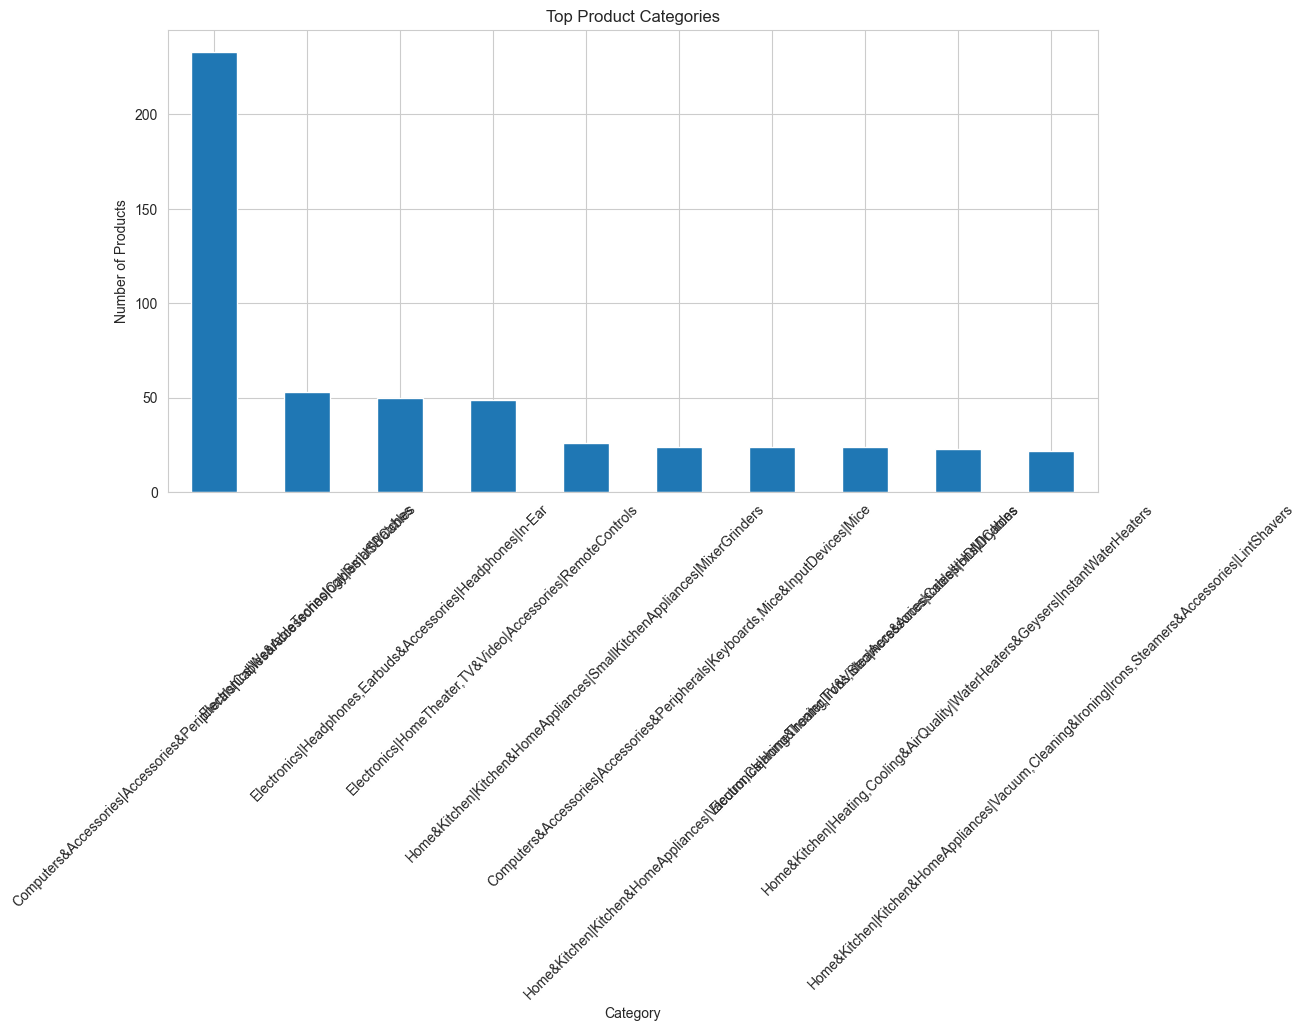

In [21]:
plt.figure(figsize=(12,6))

category_count.head(10).plot(kind="bar")

plt.title("Top Product Categories")
plt.xlabel("Category")
plt.ylabel("Number of Products")
plt.xticks(rotation=45)

plt.show()

In [22]:
top_categories = (
    df["category"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_categories.columns = [
    "category",
    "product_count"
]

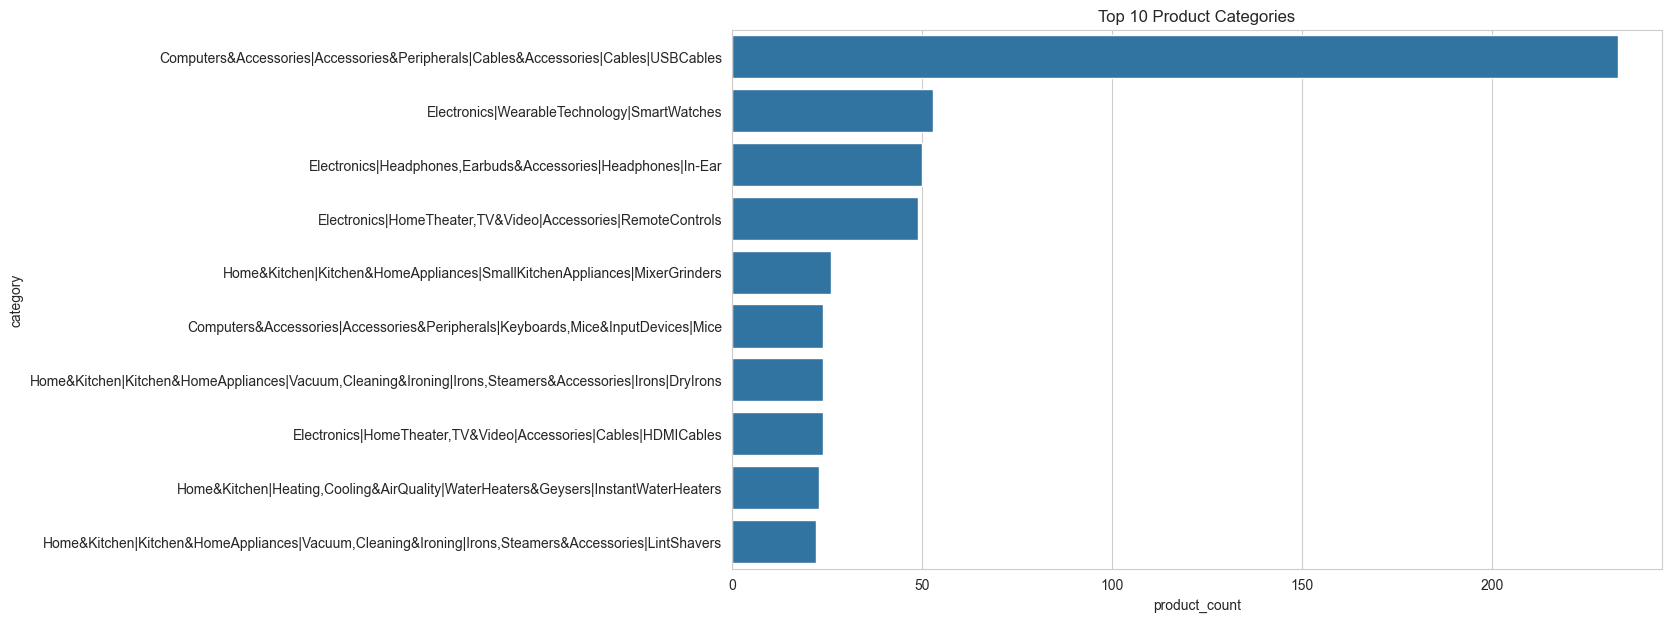

In [23]:
plt.figure(figsize=(12,7))

sns.barplot(
    data=top_categories,
    x="product_count",
    y="category"
)

plt.title("Top 10 Product Categories")

plt.show()

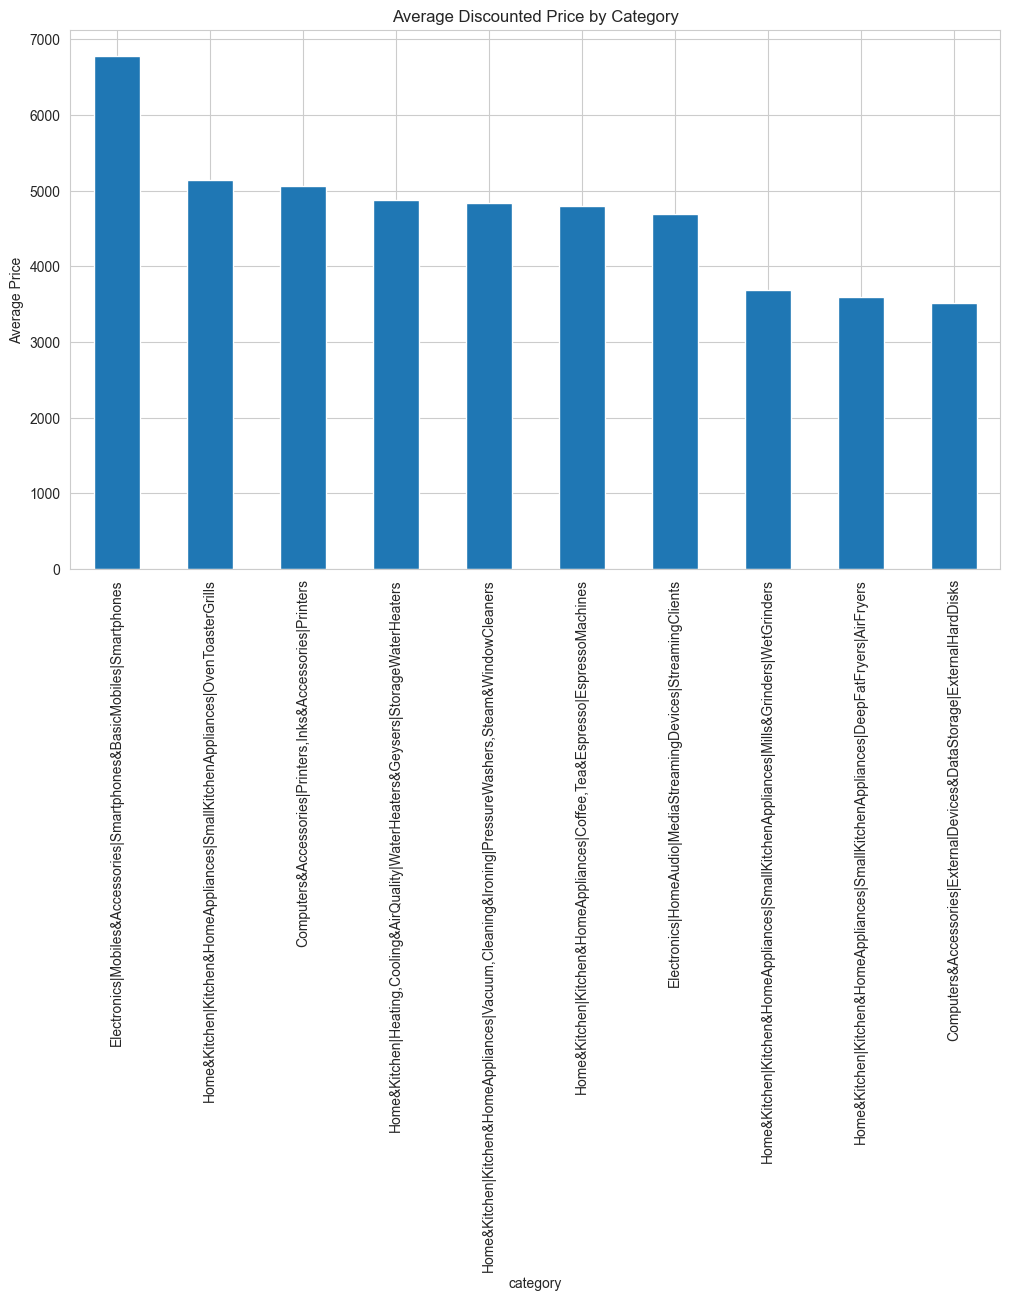

In [24]:
category_price = (
    df.groupby("category")["discounted_price"]
    .mean()
    .sort_values(ascending=False)
)

category_price.head(10) 
plt.figure(figsize=(12,7))

category_price.head(10).plot(kind="bar")

plt.title("Average Discounted Price by Category")
plt.ylabel("Average Price")

plt.show()

In [25]:
top_rated = (
    df.sort_values(
        "rating",
        ascending=False
    )
    [["product_name", "rating", "rating_count"]]
    .head(10)
)

top_rated

most_reviewed = (
    df.sort_values(
        "rating_count",
        ascending=False
    )
    [["product_name", "rating", "rating_count"]]
    .head(10)
)

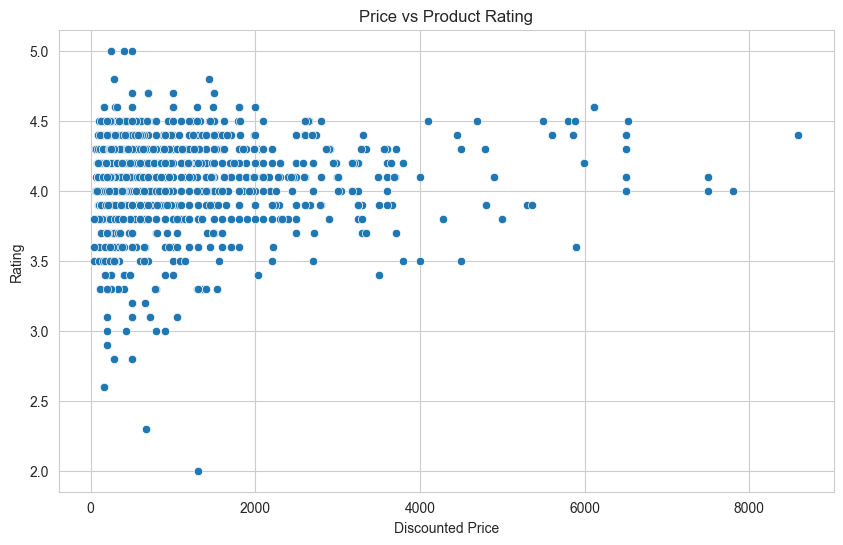

In [26]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="discounted_price",
    y="rating"
)

plt.title("Price vs Product Rating")
plt.xlabel("Discounted Price")
plt.ylabel("Rating")

plt.show()

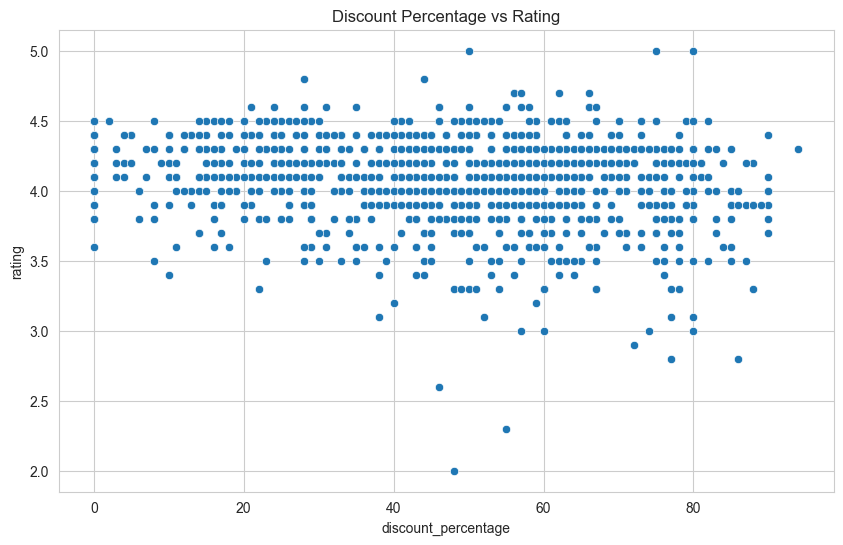

In [27]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="discount_percentage",
    y="rating"
)

plt.title("Discount Percentage vs Rating")

plt.show()

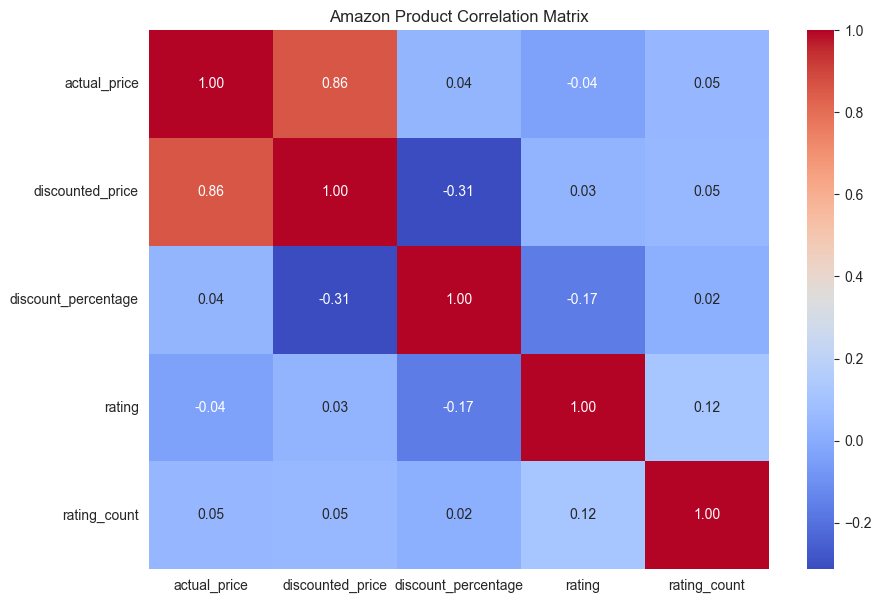

In [28]:
numeric_cols = [
    "actual_price",
    "discounted_price",
    "discount_percentage",
    "rating",
    "rating_count"
]
corr = df[numeric_cols].corr()

corr
plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Amazon Product Correlation Matrix")

plt.show()

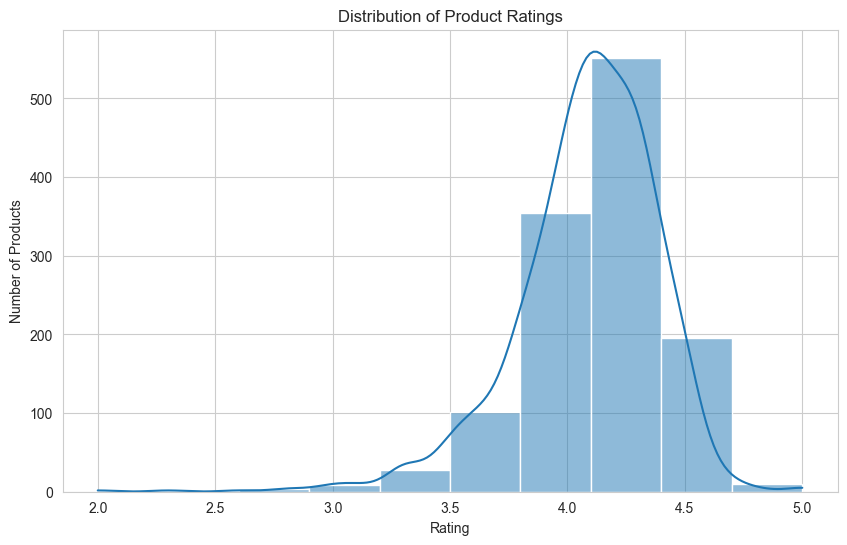

In [29]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["rating"],
    bins=10,
    kde=True
)

plt.title("Distribution of Product Ratings")

plt.xlabel("Rating")
plt.ylabel("Number of Products")

plt.show()

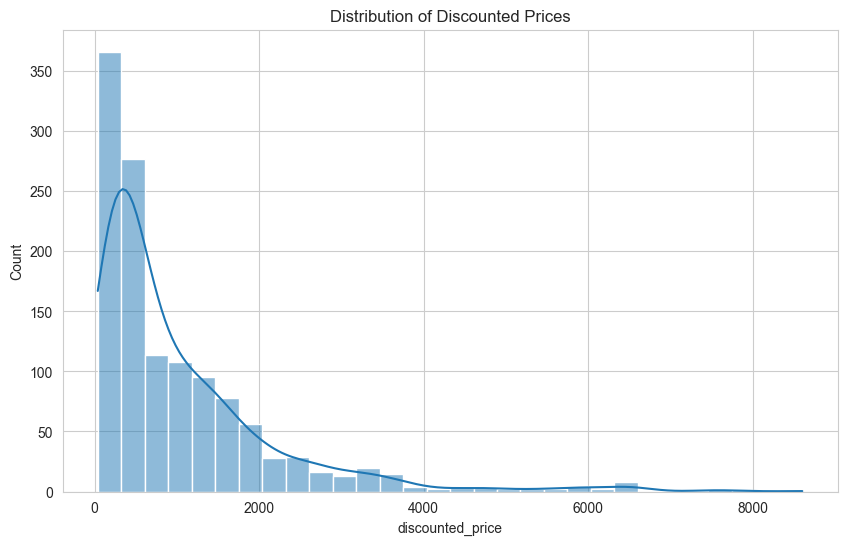

In [30]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["discounted_price"],
    bins=30,
    kde=True
)

plt.title("Distribution of Discounted Prices")

plt.show()

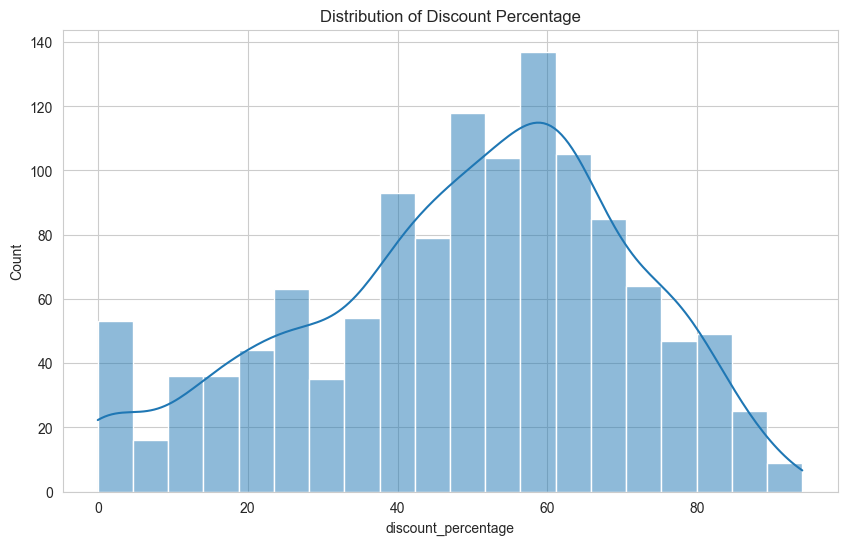

In [31]:
plt.figure(figsize=(10,6))

sns.histplot(
    df["discount_percentage"],
    bins=20,
    kde=True
)

plt.title("Distribution of Discount Percentage")

plt.show()

In [32]:
pivot = pd.pivot_table(
    df,
    values="discounted_price",
    index="price_category",
    columns="rating_category",
    aggfunc="mean"
)

pivot

rating_category,Average,Excellent,Good,Poor
price_category,,,,
High Price,3166.499333,4294.428571,3422.608317,NaN
Low Price,267.447987,284.804878,279.402827,285.0
Medium Price,1184.198397,1155.666667,1098.776833,984.0


In [33]:
category_analysis = df.groupby(
    "category"
).agg(
    total_products=("product_name", "count"),
    average_price=("discounted_price", "mean"),
    average_rating=("rating", "mean"),
    total_reviews=("rating_count", "sum")
)
category_analysis.sort_values(
    "total_reviews",
    ascending=False
).head(10)

,total_products,average_price,average_rating,total_reviews
category,,,,
Computers&Accessories|Accessories&Peripherals|LaptopAccessories|Bags&Sleeves|LaptopSleeves&Slipcases,6,360.666667,4.2500,99401133097012868109222860
"Electronics|Headphones,Earbuds&Accessories|Headphones|On-Ear",8,1113.625000,4.0625,97175107151335846002613797427759717491188
Home&Kitchen|Kitchen&HomeAppliances|SmallKitchenAppliances|DigitalKitchenScales|DigitalScales,2,519.000000,4.3000,96957
Computers&Accessories|NetworkingDevices|NetworkAdapters|BluetoothAdapters,1,599.000000,4.3000,95116
Home&Kitchen|CraftMaterials|PaintingMaterials,1,230.000000,4.5000,9427
Computers&Accessories|Accessories&Peripherals|USBHubs,5,553.000000,3.9400,93853201212516628566
"OfficeProducts|OfficePaperProducts|Paper|Stationery|Notebooks,WritingPads&Diaries|Notepads&MemoBooks",2,144.000000,4.2500,93447429
Electronics|Mobiles&Accessories|MobileAccessories|Mounts|Shower&WallMounts,1,89.000000,4.1000,9340
Electronics|Cameras&Photography|SecurityCameras|DomeCameras,5,2757.200000,4.1000,9311218803606446965554


In [34]:
category_plot = (
    df.groupby("category")
    .agg(
        products=("product_name", "count"),
        avg_rating=("rating", "mean")
    )
    .reset_index()
)
fig = px.bar(
    category_plot.sort_values(
        "products",
        ascending=False
    ).head(15),
    x="category",
    y="products",
    color="avg_rating",
    title="Top Amazon Categories"
)

fig.show()

In [35]:
fig = px.bar(
    category_plot.sort_values(
        "products",
        ascending=False
    ).head(15),
    x="category",
    y="products",
    color="avg_rating",
    title="Top Amazon Categories"
)

fig.show()

In [36]:
category_summary = (
    df.groupby("category")
    .agg(
        product_count=("product_name", "count")
    )
    .reset_index()
)
fig = px.treemap(
    category_summary,
    path=["category"],
    values="product_count",
    title="Amazon Product Category Distribution"
)

fig.show()

In [37]:
top_discount = (
    df.sort_values(
        "discount_percentage",
        ascending=False
    )
    [["product_name",
      "actual_price",
      "discounted_price",
      "discount_percentage"]]
    .head(10)
)

top_discount
fig = px.bar(
    top_discount,
    x="discount_percentage",
    y="product_name",
    orientation="h",
    title="Top 10 Products by Discount"
)

fig.show()

In [38]:
summary = df.groupby(
    "category"
).agg(
    products=("product_name", "count"),
    avg_price=("discounted_price", "mean"),
    avg_rating=("rating", "mean"),
    reviews=("rating_count", "sum"),
    avg_discount=("discount_percentage", "mean")
).reset_index()
summary.sort_values(
    "reviews",
    ascending=False
).head(10)
summary.to_csv(
    "category_summary.csv",
    index=False
)

In [39]:
df.to_csv(
    "amazon_cleaned.csv",
    index=False
)